In [47]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt


############
# parameters
############

N_arr = np.arange(2, 10, 1)
ω = ω0 = g = 1.0
tlist = np.arange(0.01, 2*np.pi, 0.0001)

#############################
# Central-Spin Hamiltonian
#############################

def central_spin(N, ω, ω0, g):
   
# ======== Spin-1/2 operators ====================
    
    sp = qt.sigmap()
    sm = qt.sigmam()
    sz = qt.sigmaz()

# ======== Embed single-spin operator =================

    def embed(op, i):
        ops = [qt.qeye(2)]* (N+1)
        ops[i] = op
        return qt.tensor(ops)

# ======== Central-spin operators ===============

    Sp = embed(sp, 0)
    Sm = embed(sm, 0)
    Sz = 0.5 * embed(sz, 0)

# ======== Collective bath operators ============

    Jp = sum(embed(sp, i + 1) for i in range(N))
    Jm = sum(embed(sm, i + 1) for i in range(N))
    Jz = 0.5 * sum(embed(sz, i + 1) for i in range(N))
    
# ======== Bath Hamiltonian ==================

    IB = qt.tensor([qt.qeye(2)]*(N+1))
    HB = Jz + 0.5 * N * IB
    

    H = ω  * Sz + ω0 * (Jz + 0.5 * N * qt.tensor([qt.qeye(2)] * (N + 1))) + (g / np.sqrt(N) * (Sp * Jm + Sm * Jp))
    
    return H, HB


##################
# Initial state
##################

def initial_state(N, state="excited"):

# ====== Central spin state ===========
  
    if state == "excited":
        psi_c = qt.basis(2, 0)

    elif state == "ground":
        psi_c = qt.basis(2, 1)


# ======= Bath state ===========

    psi_b = qt.tensor([qt.basis(2, 1) for _ in range(N)])

# ======= Total initial state ===========

    return qt.tensor(psi_c, psi_b)


##############
# Pnm matrix
##############

def pnm_matrix(rho, H):

    r_val, r_vec = rho.eigenstates()
    idx = np.argsort(r_val)[::-1]
    r_val = r_val[idx]
    r_vec = [r_vec[i] for i in idx]

    e_val, e_vec = H.eigenstates()

    pnm = np.zeros((len(e_val), len(e_val)))
    for n in range(len(e_val)):
        for m in range(len(e_val)):
            pnm[n, m] = r_val[m]*abs(e_vec[n].overlap(r_vec[m]))**2

    return pnm, r_val, e_val


############################
# ergotropy using pnm matrix
############################

def ergotropy_pnm(pnm, r_val, e_val):
    deltaE = e_val[:,None] - e_val[None,:]
    return np.sum(pnm * deltaE)


############################
# variance using pnm matrix
############################

def variance_pnm(pnm, r_val, e_val):
    deltaE2 = (e_val[:,None] - e_val[None,:])**2
    mean2 = np.sum(pnm * deltaE2)
    mean = ergotropy_pnm(pnm, r_val, e_val)
    return mean2 - mean**2

N= 2, τ=1.1800, E_B=0.847782
N= 3, τ=1.1800, E_B=0.847782
N= 4, τ=1.1800, E_B=0.847782
N= 5, τ=1.1800, E_B=0.847782
N= 6, τ=1.1800, E_B=0.847782
N= 7, τ=1.1800, E_B=0.847782
N= 8, τ=1.1800, E_B=0.847782
N= 9, τ=1.1800, E_B=0.847782


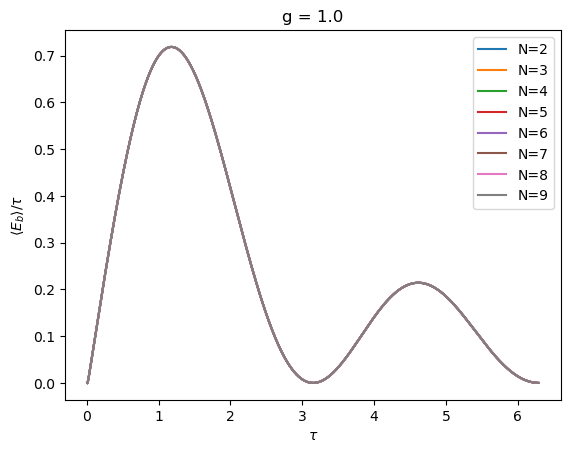

In [48]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

N_arr = np.arange(2, 10, 1)
nmax = 60
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, (2*np.pi), 0.0001)

##############################################
# Plot Battery energy <Eb> as function of time 
# and pick time τ for which <Eb> is maximum
##############################################
τ_list = []

for N in N_arr:

    H, HB = central_spin(N, ω, ω0, g)

    # Initial state
    ψ0 = initial_state(N, "excited")

    opts = qt.Options(atol=1e-16, rtol=1e-14)        ## ODE solver options
    # Time evolution
    result = qt.sesolve(H, ψ0, tlist, e_ops=HB, options=opts)

    # Battery energy vs time
    Eb_list = np.array(result.expect[0])

    # Maximize charging power (Eb / t)
    power = Eb_list / tlist
    
    idx = np.argmax(power)
    
    τ = tlist[idx]
    
    τ_list.append(τ)

    print(f"N={N:2d}, τ={tlist[idx]:.4f}, E_B={Eb_list[idx]:.6f}")
    
    ##################################
    # Plot of battery energy with time
    ##################################
    
    plt.plot(tlist, power, label=f"N={N}")

plt.xlabel(r"$\tau$")
plt.ylabel(r"$\langle E_b \rangle / \tau$")
plt.legend()
plt.title(f"g = {g}")
plt.show()

N= 2, τ=1.1800, Eb=0.854896, Ergotropy=0.854896, erg/Eb=1.000000000000 Variance=1.2404863173e-01
N= 3, τ=1.1800, Eb=0.854896, Ergotropy=0.854896, erg/Eb=1.000000000000 Variance=1.2404863173e-01
N= 4, τ=1.1800, Eb=0.854896, Ergotropy=0.854896, erg/Eb=1.000000000000 Variance=1.2404863173e-01
N= 5, τ=1.1800, Eb=0.854896, Ergotropy=0.854896, erg/Eb=1.000000000000 Variance=1.2404863173e-01
N= 6, τ=1.1800, Eb=0.854896, Ergotropy=0.854896, erg/Eb=1.000000000000 Variance=1.2404863173e-01
N= 7, τ=1.1800, Eb=0.854896, Ergotropy=0.854896, erg/Eb=1.000000000000 Variance=1.2404863173e-01
N= 8, τ=1.1800, Eb=0.854896, Ergotropy=0.854896, erg/Eb=1.000000000000 Variance=1.2404863173e-01
N= 9, τ=1.1800, Eb=0.854896, Ergotropy=0.854896, erg/Eb=1.000000000000 Variance=1.2404863173e-01


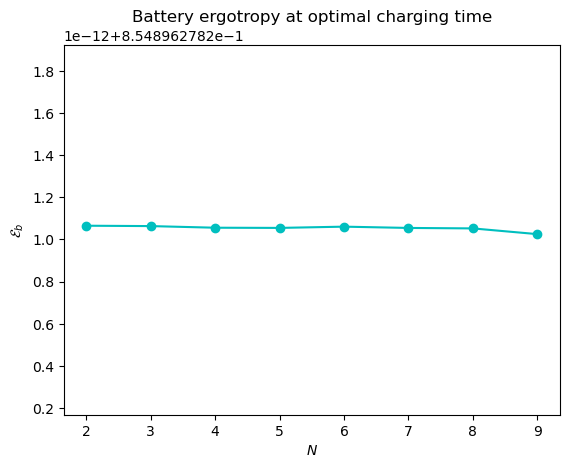

In [49]:
Eb_list = []
erg_list = []
var_list = []
ratio_list = []

for i, N in enumerate(N_arr):

    τ = τ_list[i]

    # Rebuild Hamiltonian
    H, HB = central_spin(N, ω, ω0, g)

    # Initial state
    ψ0 = initial_state(N, "excited")

    # Evolve until τ
    result = qt.sesolve(H, ψ0, [0, τ], options=opts)

    # Full density matrix at τ
    ρ_full = result.states[-1]

    # Partial trace over cavity (subsystem 0)
    ρb = qt.ket2dm(ρ_full)

    Eb = qt.expect(HB, ρb)
    
    pnm, r_val, e_val = pnm_matrix(ρb, HB)

    # Ergotropy via pnm matrix
    erg = ergotropy_pnm(pnm, r_val, e_val)

    # Variance via pnm matrix
    var = variance_pnm(pnm, r_val, e_val)

    ratio = erg/Eb

    print(f"N={N:2d}, τ={τ:.4f}, Eb={Eb:.6f}, Ergotropy={erg:.6f}, erg/Eb={ratio:.12f} Variance={var:.10e}")

    Eb_list.append(Eb)
    erg_list.append(erg)
    var_list.append(var)
    ratio_list.append(ratio)

Eb_arr = np.array(Eb_list)
erg_arr = np.array(erg_list)
var_arr = np.array(var_list)

rel_fluct = np.sqrt(var_arr) / erg_arr

rel_fluc = np.sqrt(var_arr) / Eb_arr

###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.figure()
plt.plot(N_arr, erg_list, 'o-', color='c')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
#plt.savefig("WS1.png")
plt.show()

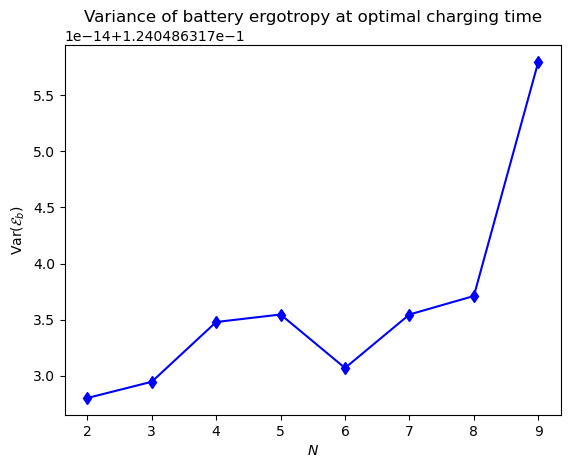

In [50]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, var_list, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
#plt.savefig("WS2.png")
plt.show()

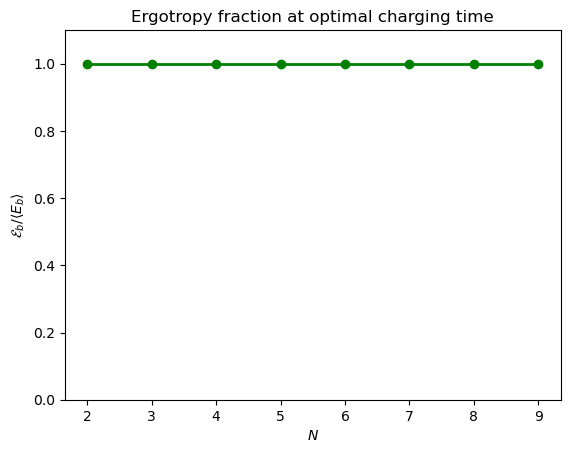

In [51]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
#############################################################


plt.figure()
plt.plot(N_arr, ratio_list, 'o-', color='g', linewidth=2)
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
#plt.savefig("WS3.png")
plt.show()

N= 2, τ=1.1800, Relative Fluctuation =0.411986099219, Relative Fluctuation with Eb =0.411986099219
N= 3, τ=1.1800, Relative Fluctuation =0.411986099220, Relative Fluctuation with Eb =0.411986099220
N= 4, τ=1.1800, Relative Fluctuation =0.411986099220, Relative Fluctuation with Eb =0.411986099220
N= 5, τ=1.1800, Relative Fluctuation =0.411986099220, Relative Fluctuation with Eb =0.411986099220
N= 6, τ=1.1800, Relative Fluctuation =0.411986099220, Relative Fluctuation with Eb =0.411986099220
N= 7, τ=1.1800, Relative Fluctuation =0.411986099220, Relative Fluctuation with Eb =0.411986099220
N= 8, τ=1.1800, Relative Fluctuation =0.411986099220, Relative Fluctuation with Eb =0.411986099220
N= 9, τ=1.1800, Relative Fluctuation =0.411986099220, Relative Fluctuation with Eb =0.411986099220


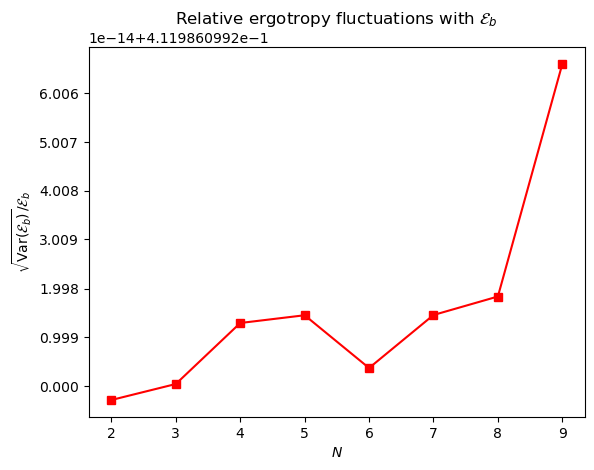

In [52]:
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.4f}, Relative Fluctuation ={rel_fluct[idx]:.12f}, Relative Fluctuation with Eb ={rel_fluc[idx]:.12f}")

#######################################################################
# Plot fluctuations w.r.t ergotropy as a function of g for different N 
#######################################################################

plt.figure()
plt.plot(N_arr, rel_fluct, 's-', color='r')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations with $\mathcal{E}_b$")
#plt.savefig("WS4.png")
plt.show()

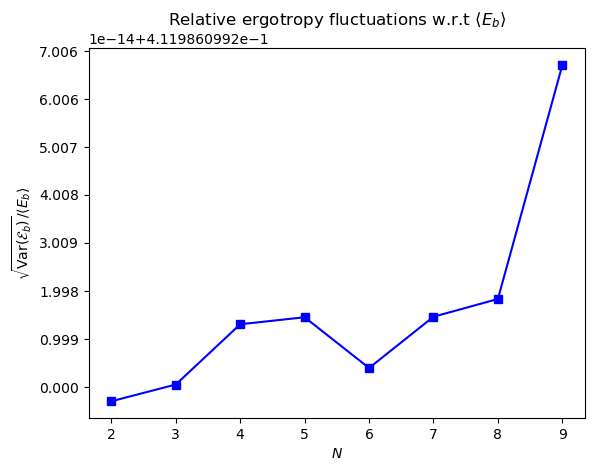

In [53]:
############################################################################
# Plot fluctuations w.r.t battery energy as a function of g for different N 
############################################################################

plt.figure()
plt.plot(N_arr, rel_fluc, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
#plt.savefig("WS5.png")
plt.show()

In [57]:
# =========================
# Check ground state of HB
# =========================

evals, evecs = HB.eigenstates()

# all spins up
psi0_all = qt.tensor(
    [qt.basis(2,0) for _ in range(N+1)]
)

# all spins down
psi1_all = qt.tensor(
    [qt.basis(2,1) for _ in range(N+1)]
)

E0 = qt.expect(HB, psi0_all)
E1 = qt.expect(HB, psi1_all)

print(f"\nN = {N}")
print(f"Ground energy (from diagonalization): {evals[0]:.4f}")
print(f"Energy of |0...0>: {E0:.4f}")
print(f"Energy of |1...1>: {E1:.4f}")

print(
    "Is |0...0> ground state?",
    np.isclose(E0, evals[0])
)

print(
    "Is |1...1> ground state?",
    np.isclose(E1, evals[0])
)


N = 9
Ground energy (from diagonalization): 0.0000
Energy of |0...0>: 9.0000
Energy of |1...1>: 0.0000
Is |0...0> ground state? False
Is |1...1> ground state? True
